# Perform single-cell quality control

In this notebook, we perform single-cell quality control using coSMicQC. We filter the single cells by identifying outliers with z-scores, and use either combinations of features or one feature for each condition. 

In [1]:
import os
import pathlib
import re
import json

import matplotlib

matplotlib.use("Agg")  # Ensures no GUI windows are opened
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from cytodataframe import CytoDataFrame
from cosmicqc import find_outliers

## Set paths and variables

In [2]:
# Optional: set `BATCH` and `PLATEMAP_LAYOUT` env vars to process a specific batch and platemap
batch_to_process = os.environ.get("BATCH", "batch_1")
print(f"Processing batch: {batch_to_process}")

# Set base directory for where the SQLite files are located (should be local to repo)
base_dir = pathlib.Path(
    f"../../2.cellprofiler_processing/cp_output/{batch_to_process}"
).resolve(strict=True)

Processing batch: batch_1


In [3]:
# Parameters
platemap_layout = "platemap_4"
plate_id = "CARD-CelIns-CX7_251212100001"

In [4]:
# Directory with data
data_dir = pathlib.Path(
    f"../data/{batch_to_process}/{platemap_layout}/converted_profiles/"
).resolve(strict=True)

# Path to main JSON file
thresholds_json_path = pathlib.Path("../sc_qc_thresholds.json")

# Load existing thresholds from json file if it exists, otherwise start with empty dictionary
if thresholds_json_path.exists():
    with open(thresholds_json_path, "r") as f:
        qc_thresholds_dict = json.load(f)
        print(f"Loaded existing thresholds from {thresholds_json_path}")
else:
    qc_thresholds_dict = {}
    print(
        f"No existing thresholds file found at {thresholds_json_path}, starting with empty dictionary."
    )

# Set the layout and plate keys in the dictionary
layout_dict = qc_thresholds_dict.setdefault(platemap_layout, {})
plate_dict = layout_dict.setdefault(plate_id, {})

# Metadata columns to include in output data frame (based on compartment)
nuclei_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_PathName_DNA",
    "Image_FileName_DNA",
    "Nuclei_AreaShape_BoundingBoxMaximum_X",
    "Nuclei_AreaShape_BoundingBoxMaximum_Y",
    "Nuclei_AreaShape_BoundingBoxMinimum_X",
    "Nuclei_AreaShape_BoundingBoxMinimum_Y",
]
cells_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Cells_Location_Center_X",
    "Metadata_Cells_Location_Center_Y",
    "Image_PathName_DNA",
    "Image_FileName_DNA",
    "Image_PathName_Actin",
    "Image_FileName_Actin",
    "Cells_AreaShape_BoundingBoxMaximum_X",
    "Cells_AreaShape_BoundingBoxMaximum_Y",
    "Cells_AreaShape_BoundingBoxMinimum_X",
    "Cells_AreaShape_BoundingBoxMinimum_Y",
]

Loaded existing thresholds from ../sc_qc_thresholds.json


## Load in plate to perform QC on

In [5]:
# Set plate path
plate_path = pathlib.Path(f"{data_dir}/{plate_id}_converted.parquet").resolve(
    strict=True
)

# Load the converted plate data
plate_df = pd.read_parquet(plate_path)

# Print the shape of the DataFrame for each plate
print(f"Loaded plate: {plate_path.stem}, Shape: {plate_df.shape}")

Loaded plate: CARD-CelIns-CX7_251212100001_converted, Shape: (11596, 2476)


## Correct pathing to local to find images

In [6]:
# Fix image paths to point to corrected images
correct_parent = "/home/jenna"

for col in plate_df.columns:
    if "PathName" in col and "Illum" not in col:
        plate_df[col] = plate_df[col].apply(
            lambda x: (
                re.sub(r"^.*jtomkinson@xsede.org/", correct_parent + "/", x)
                if isinstance(x, str)
                else x
            )
        )
        # Update the folder name from 1.illumination_correction to 1b.illumination_correction
        plate_df[col] = plate_df[col].str.replace(
            "1.illumination_correction", "1b.illumination_correction"
        )

# Print example image path after fix
print(plate_df["Image_PathName_DNA"].dropna().iloc[0])

/home/jenna/targeted_fibrosis_drug_screen/1b.illumination_correction/Corrected_Images/batch_1/platemap_4/CARD-CelIns-CX7_251212100001


In [7]:
# Print example image file
print(plate_df["Image_FileName_DNA"].dropna().iloc[0])

CARD-CelIns-CX7_251212100001_B02f17d4_illumcorrect.tiff


## Set mapping for outlines

In [8]:
# Define available compartments
compartments = ["Nuclei", "Cells"]

# Create a dictionary of mappings for each compartment
mapping_dict = {
    comp: {
        rf"{comp}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff": rf"{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}{record['Image_Metadata_Site']}.*\.tiff"
        for record in plate_df[
            ["Image_Metadata_Plate", "Image_Metadata_Well", "Image_Metadata_Site"]
        ].to_dict(orient="records")
    }
    for comp in compartments
}

## Detect over-segmented nuclei using shape and intensity

In [9]:
# Set mapping for Nuclei compartment
outline_to_orig_mapping = mapping_dict["Nuclei"]

Number of outliers: 207 (1.79%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.6591462632995769
Nuclei_AreaShape_Solidity Max: 0.9653870358716173
Nuclei_Intensity_MassDisplacement_DNA Min: 1.46882825333957
Nuclei_Intensity_MassDisplacement_DNA Max: 49.34467793730936
(207, 5)


,3180,8900,10728,9257,1292
Image_Metadata_Well,E02,C02,F11,F05,B03
Image_Metadata_Site,f05,f13,f16,f24,f04
Nuclei_AreaShape_Solidity,0.955951,0.944593,0.899281,0.900864,0.924685
Nuclei_Intensity_MassDisplacement_DNA,5.429674,4.298552,2.056631,3.989058,5.931764
Image_FileName_DNA,,,,,

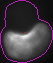
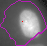
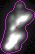
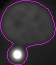
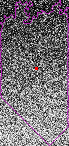

In [10]:
feature_thresholds_oversegmented_nuclei = {
    "Nuclei_AreaShape_Solidity": -0.5,
    "Nuclei_Intensity_MassDisplacement_DNA": 1.4,
}

# Save thresholds to dictionary for current condition
plate_dict["oversegmented_nuclei"] = feature_thresholds_oversegmented_nuclei

# Find large nuclei outliers for the current plate
oversegmented_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=nuclei_metadata_columns,
    feature_thresholds=feature_thresholds_oversegmented_nuclei,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
oversegmented_nuclei_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(oversegmented_nuclei_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 10,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Nuclei_AreaShape_Solidity",
        "Nuclei_Intensity_MassDisplacement_DNA",
        "Image_FileName_DNA",
    ]
]

if not oversegmented_nuclei_outliers_cdf.empty:
    print(oversegmented_nuclei_outliers_cdf.shape)
    # display(
    #     oversegmented_nuclei_outliers_cdf.sort_values(
    #         by="Nuclei_AreaShape_Solidity", ascending=False
    #     )
    #     .head(5)
    #     .T
    # )
    display(oversegmented_nuclei_outliers_cdf.sample(n=5).T)
else:
    print("No oversegmented nuclei outliers detected.")

## Detect mis-segmented background as nuclei

Number of outliers: 78 (0.67%)
Outliers Range:
Nuclei_Intensity_MeanIntensity_DNA Min: 0.0007766777759551499
Nuclei_Intensity_MeanIntensity_DNA Max: 0.02709716861444763


,8375,8922,3467,7021,3850
Image_Metadata_Well,F05,D06,E10,F05,D10
Image_Metadata_Site,f21,f24,f13,f18,f11
Nuclei_Intensity_MeanIntensity_DNA,0.027097,0.026985,0.026909,0.026795,0.026769
Image_FileName_DNA,,,,,

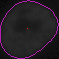
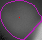
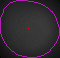
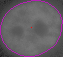

In [11]:
# Set feature thresholds for low total intensity
feature_thresholds_low_intensity = {
    "Nuclei_Intensity_MeanIntensity_DNA": -1.8,
}

# Save thresholds to dictionary for current condition
plate_dict["low_intensity_nuclei"] = feature_thresholds_low_intensity

# Find low intensity nuclei outliers for the current plate
low_intensity_outliers = find_outliers(
    df=plate_df,
    metadata_columns=nuclei_metadata_columns,
    feature_thresholds=feature_thresholds_low_intensity,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
low_intensity_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(low_intensity_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 10,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Nuclei_Intensity_MeanIntensity_DNA",
        "Image_FileName_DNA",
    ]
]

if not low_intensity_outliers_cdf.empty:
    display(
        low_intensity_outliers_cdf.sort_values(
            by="Nuclei_Intensity_MeanIntensity_DNA", ascending=False
        )
        .head(5)
        .T
    )
    # display(low_intensity_outliers_cdf.sample(n=5, random_state=0).T)
else:
    print("No low intensity nuclei outliers detected.")

## Detect under-segmented cells

In [12]:
# Set mapping for Cells compartment
outline_to_orig_mapping = mapping_dict["Cells"]

Number of outliers: 418 (3.60%)
Outliers Range:
Cells_AreaShape_Area Min: 735.0
Cells_AreaShape_Area Max: 4691.0
(418, 5)


,2708,10346,14,11385,704
Image_Metadata_Well,D07,E06,B08,C09,F08
Image_Metadata_Site,f14,f09,f05,f14,f06
Cells_AreaShape_Area,4691.0,4683.0,4678.0,4678.0,4664.0
Image_FileName_Actin,,,,,
Image_FileName_DNA,,,,,

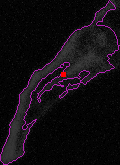
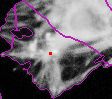
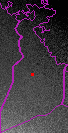
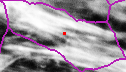
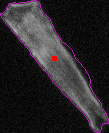
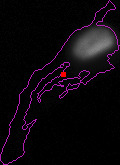
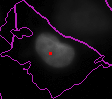
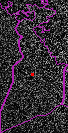
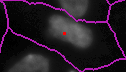
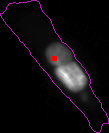

In [13]:
# Set feature thresholds for small cells
feature_thresholds_small_cells = {
    "Cells_AreaShape_Area": -1.5,
}

# Save thresholds to dictionary for current condition
plate_dict["undersegmented_cells"] = feature_thresholds_small_cells

# Find under-segmented cells outliers for the current plate
small_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=cells_metadata_columns,
    feature_thresholds=feature_thresholds_small_cells,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
small_cells_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(small_cells_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 1,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Cells_AreaShape_Area",
        "Image_FileName_Actin",
        "Image_FileName_DNA",
    ]
]

if not small_cells_outliers_cdf.empty:
    print(small_cells_outliers_cdf.shape)
    display(
        small_cells_outliers_cdf.sort_values(by="Cells_AreaShape_Area", ascending=False)
        .head(5)
        .T
    )
else:
    print("No small cells outliers detected.")

## Detect blurry/out-of-focus cells

Number of outliers: 1565 (13.50%)
Outliers Range:
Cells_Granularity_1_Actin Min: -2.585918595742152
Cells_Granularity_1_Actin Max: 9.212045235703183
(1565, 7)


,4759,405,10889,3563,2860
Image_Metadata_Plate,CARD-CelIns-CX7_251212100001,CARD-CelIns-CX7_251212100001,CARD-CelIns-CX7_251212100001,CARD-CelIns-CX7_251212100001,CARD-CelIns-CX7_251212100001
Image_Metadata_Well,G09,C03,C09,E06,C11
Image_Metadata_Site,f15,f10,f04,f06,f24
Cells_Granularity_1_Actin,9.212045,9.210816,9.208403,9.20837,9.206618
Image_FileName_Actin,,,,,
Metadata_Cells_Location_Center_X,340.10332,702.926683,862.524476,288.663502,547.413994
Metadata_Cells_Location_Center_Y,653.518913,197.958344,662.763727,434.495076,340.563574

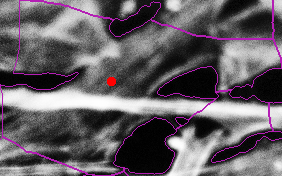
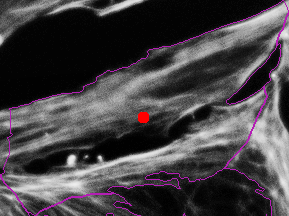
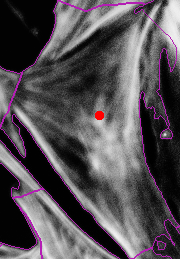
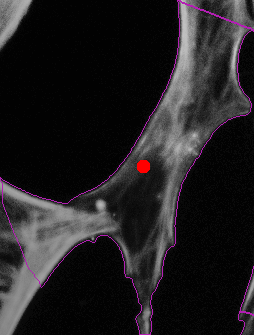
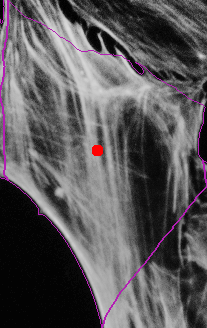

In [14]:
# find blurry cells
feature_thresholds_blurry_cells = {"Cells_Granularity_1_Actin": -1}

# Save thresholds to dictionary for current condition
plate_dict["blurry_cells"] = feature_thresholds_blurry_cells

blurry_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=cells_metadata_columns,
    feature_thresholds=feature_thresholds_blurry_cells,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
blurry_cells_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(blurry_cells_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 1,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Plate",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Cells_Granularity_1_Actin",
        "Image_FileName_Actin",
        "Metadata_Cells_Location_Center_X",
        "Metadata_Cells_Location_Center_Y",
    ]
]

if not blurry_cells_outliers_cdf.empty:
    print(blurry_cells_outliers_cdf.shape)
    display(
        blurry_cells_outliers_cdf.sort_values(
            by="Cells_Granularity_1_Actin", ascending=False
        )
        .head(5)
        .T
    )
else:
    print("No blurry cells outliers detected.")

## Take the dictionary and save to main JSON file

In [15]:
# Save the thresholds dictionary to a json file for use in main QC notebook
with open(thresholds_json_path, "w") as f:
    json.dump(qc_thresholds_dict, f, indent=4)
    print(
        f"Saved thresholds to {thresholds_json_path} for layout {platemap_layout} and plate {plate_id}"
    )

Saved thresholds to ../sc_qc_thresholds.json for layout platemap_4 and plate CARD-CelIns-CX7_251212100001
